# 🟠 Theme 10: 로지스틱 회귀 및 모델링 프로세스 최적화 (2026-04-28)

## 1. 학습 목표
- 로지스틱 회귀(Logistic Regression)의 원리를 이해하고 이진 분류 모델을 구축합니다.
- 교차 검증(Cross Validation)의 필요성을 이해하고 K-Fold 방식을 실습합니다.
- GridSearchCV를 활용하여 모델의 최적 하이퍼파라미터를 탐색하는 과정을 익힙니다.

## 2. 라이브러리 및 데이터 준비

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
%config InlineBackend.figure_format = 'retina'

## 3. 로지스틱 회귀 (Logistic Regression)
### 3.1. 모델링 및 평가

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

iris = pd.read_csv('content/iris.csv')

# 모델 생성
model = LogisticRegression()

target = 'Species'

x = iris.drop(target, axis=1)
y = iris[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

# 학습 및 예측 (데이터 준비 후 진행)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[14  0  0]
 [ 0 17  1]
 [ 0  0 13]]
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        14
  versicolor       1.00      0.94      0.97        18
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



### 규제

학습 성능: 0.9803903050465909
평가 성능: 0.8476766578971902


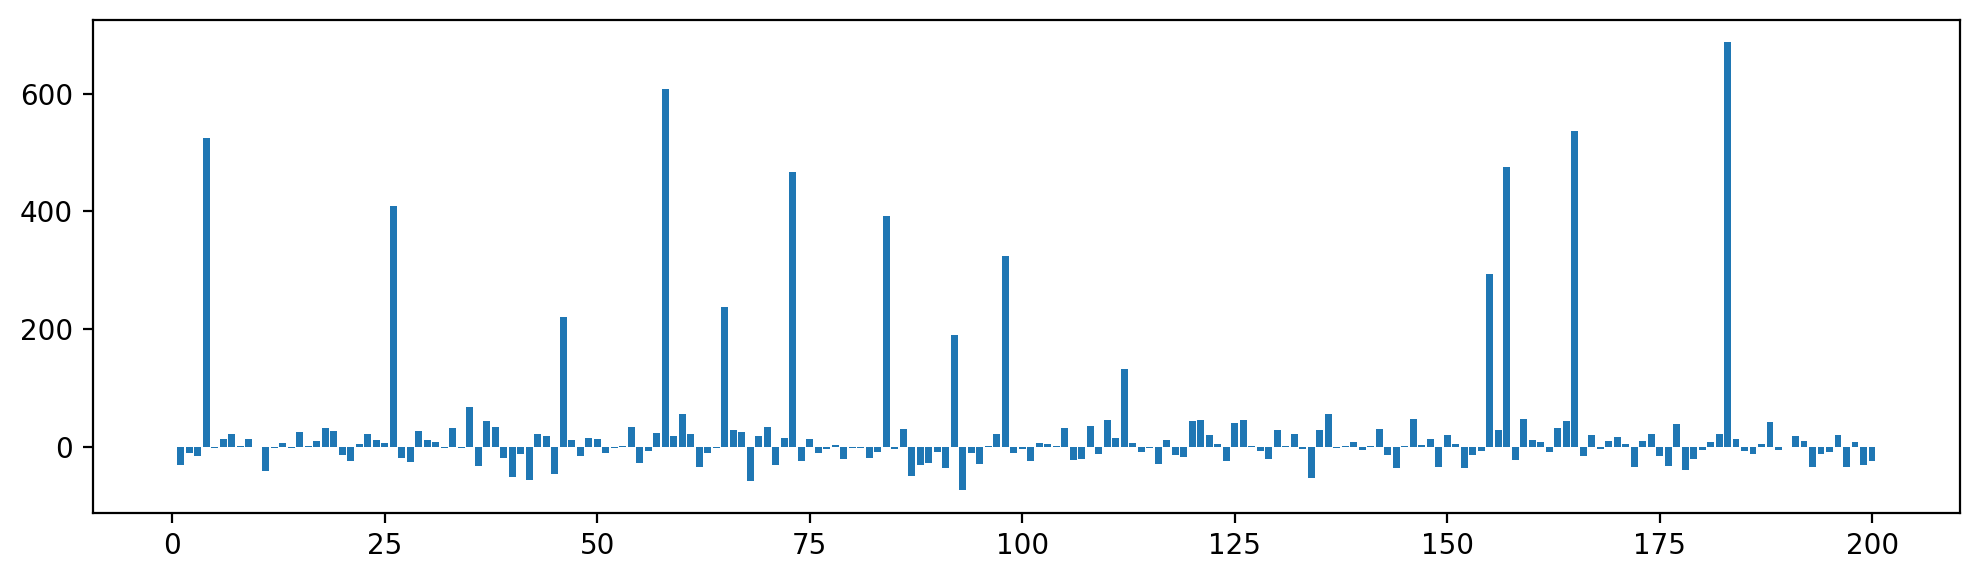

In [14]:
from sklearn.datasets import make_regression
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression

X, y, c = make_regression(n_samples=500,            # 500개 
                          n_features=200,
                          n_informative=15,
                          bias=1,
                          noise=60,
                          coef=True,
                          random_state=1)

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y, 
                                                    train_size=0.7,
                                                    random_state=1)

scaler = MinMaxScaler()
scaler.fit(X_train)
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)


model = LinearRegression()

model.fit(X_train, y_train)

print('학습 성능:', model.score(X_train, y_train))
print('평가 성능:', model.score(X_test, y_test))

plt.figure(figsize=(10,3))
plt.bar(x=range(1, 201), height=model.coef_)
plt.tight_layout()
plt.show()

Ridge 학습 성능: 0.7687584998394299
Ridge 평가 성능: 0.550193674139673
선택된 최적의 Alpha: 0.1
학습 성능: 0.9801563948141703
평가 성능: 0.8539352125522557


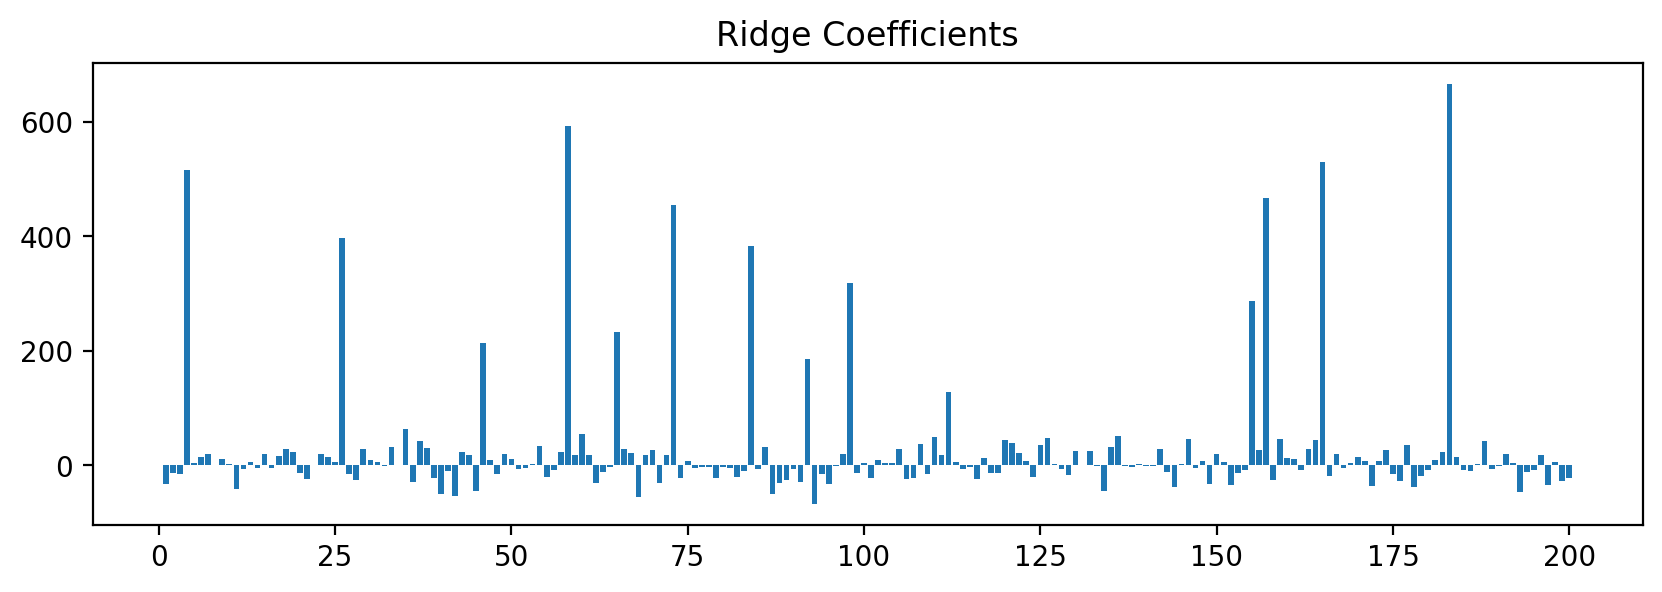

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

# alpha는 규제의 강도를 조절합니다. (클수록 규제가 강해짐)
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)

print('Ridge 학습 성능:', ridge.score(X_train, y_train))
print('Ridge 평가 성능:', ridge.score(X_test, y_test))

# 테스트할 alpha 후보군 리스트
alphas = [0.01, 0.1, 1, 10, 100]

# cv=5 는 5-Fold 교차 검증을 의미합니다.
ridge_cv = RidgeCV(alphas=alphas, cv=5)
ridge_cv.fit(X_train, y_train)

print(f'선택된 최적의 Alpha: {ridge_cv.alpha_}')
print(f'학습 성능: {ridge_cv.score(X_train, y_train)}')
print(f'평가 성능: {ridge_cv.score(X_test, y_test)}')

# 가중치 시각화
plt.figure(figsize=(10,3))
plt.bar(x=range(1, 201), height=ridge_cv.coef_)
plt.title('Ridge Coefficients')
plt.show()



Lasso 학습 성능: 0.9666534755964158
Lasso 평가 성능: 0.923906840657825
사용한 변수 개수: 55
선택된 최적의 Alpha: 0.6979070822602653
학습 성능: 0.9617654977727905
평가 성능: 0.9237459593051283
사용한 변수 개수: 37


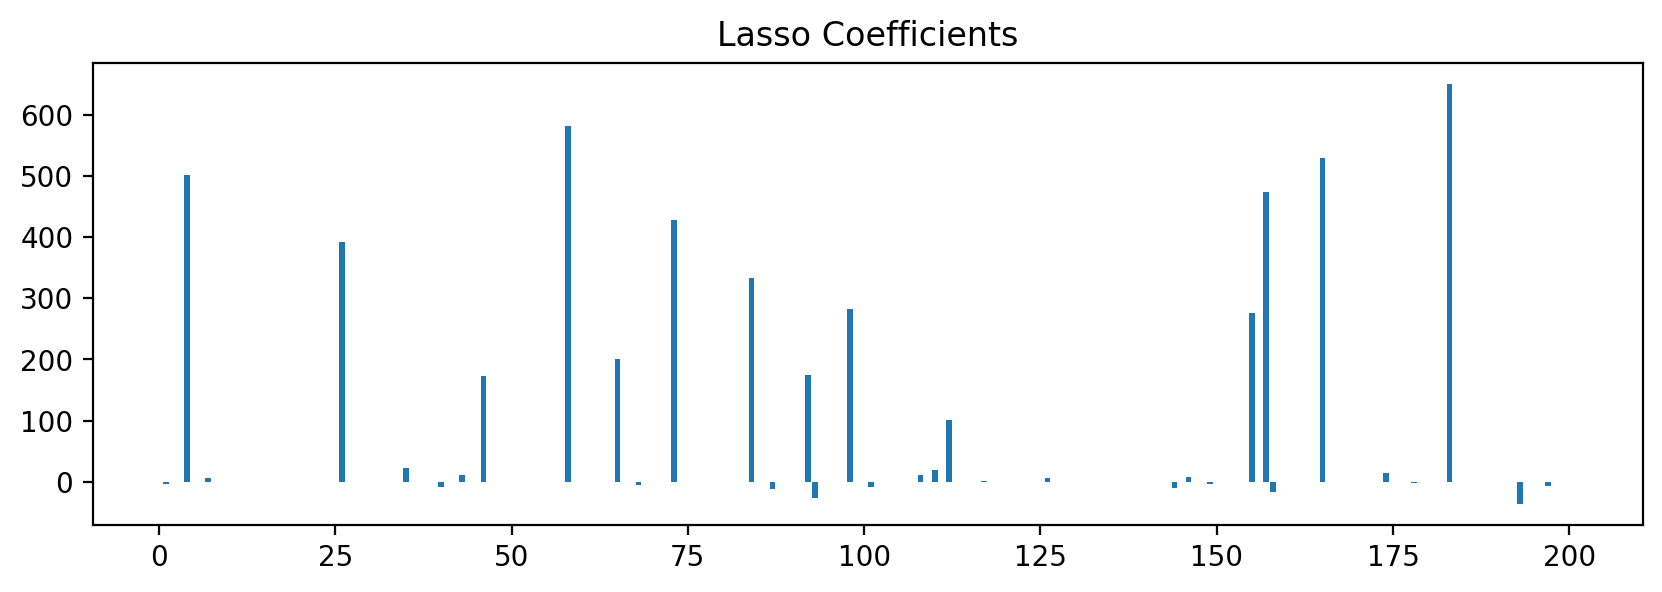

In [57]:
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

# Lasso는 일부 가중치를 0으로 만듭니다.
lasso = Lasso(alpha=0.5)
lasso.fit(X_train, y_train)

print('Lasso 학습 성능:', lasso.score(X_train, y_train))
print('Lasso 평가 성능:', lasso.score(X_test, y_test))

# 사용된 변수 개수 확인
print('사용한 변수 개수:', np.sum(lasso.coef_ != 0))

# LassoCV는 보통 alphas를 생략하면 모델이 알아서 100개 정도의 후보군을 테스트합니다.
# n_alphas=100 (기본값)
lasso_cv = LassoCV(cv=5, random_state=1)
lasso_cv.fit(X_train, y_train)
print(f'선택된 최적의 Alpha: {lasso_cv.alpha_}')
print(f'학습 성능: {lasso_cv.score(X_train, y_train)}')
print(f'평가 성능: {lasso_cv.score(X_test, y_test)}')
# 선택된 변수 개수 확인
print(f'사용한 변수 개수: {np.sum(lasso_cv.coef_ != 0)}')


# 가중치 시각화
plt.figure(figsize=(10,3))
plt.bar(x=range(1, 201), height=lasso_cv.coef_)
plt.title('Lasso Coefficients')
plt.show()


In [59]:
from sklearn.linear_model import ElasticNet, ElasticNetCV

# 모델 생성 및 학습
# l1_ratio=0.5 는 L1과 L2 규제를 반반씩 섞겠다는 의미입니다.
elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
elastic.fit(X_train, y_train)

print(f'ElasticNet 학습 성능: {elastic.score(X_train, y_train)}')
print(f'ElasticNet 평가 성능: {elastic.score(X_test, y_test)}')

# 최적의 조합을 찾고 싶다면 ElasticNetCV를 사용하세요!
elastic_cv = ElasticNetCV(l1_ratio=[.1, .5, .7, .9, .95, .99, 1], cv=5)
elastic_cv.fit(X_train, y_train)
print(f'선택된 최적의 l1_ratio: {elastic_cv.l1_ratio_}')
print(f'ElasticNet 학습 성능: {elastic_cv.score(X_train, y_train)}')
print(f'ElasticNet 평가 성능: {elastic_cv.score(X_test, y_test)}')

ElasticNet 학습 성능: 0.6445363964178785
ElasticNet 평가 성능: 0.4380586163822955
선택된 최적의 l1_ratio: 1.0
ElasticNet 학습 성능: 0.9617654977727905
ElasticNet 평가 성능: 0.9237459593051283


- KNN 알고리즘을 사용하기 위해 정규화 진행

✅ (올바른 방법) 학습 데이터의 최소/최댓값으로 평가 데이터 정규화
- 이렇게 하면 학습과 평가 과정에서 데이터 분포가 일관되게 유지됨
- 이 방법을 사용해야 모델이 올바르게 평가될 수 있음

❌ (잘못된 방법) 평가 데이터의 최소/최댓값으로 정규화
- 이렇게 되면 평가 데이터가 모델이 학습한 데이터 분포와 달라져 모델 성능이 왜곡됨
- 평가 과정에서 예상치 못한 결과가 나올 가능성이 커짐

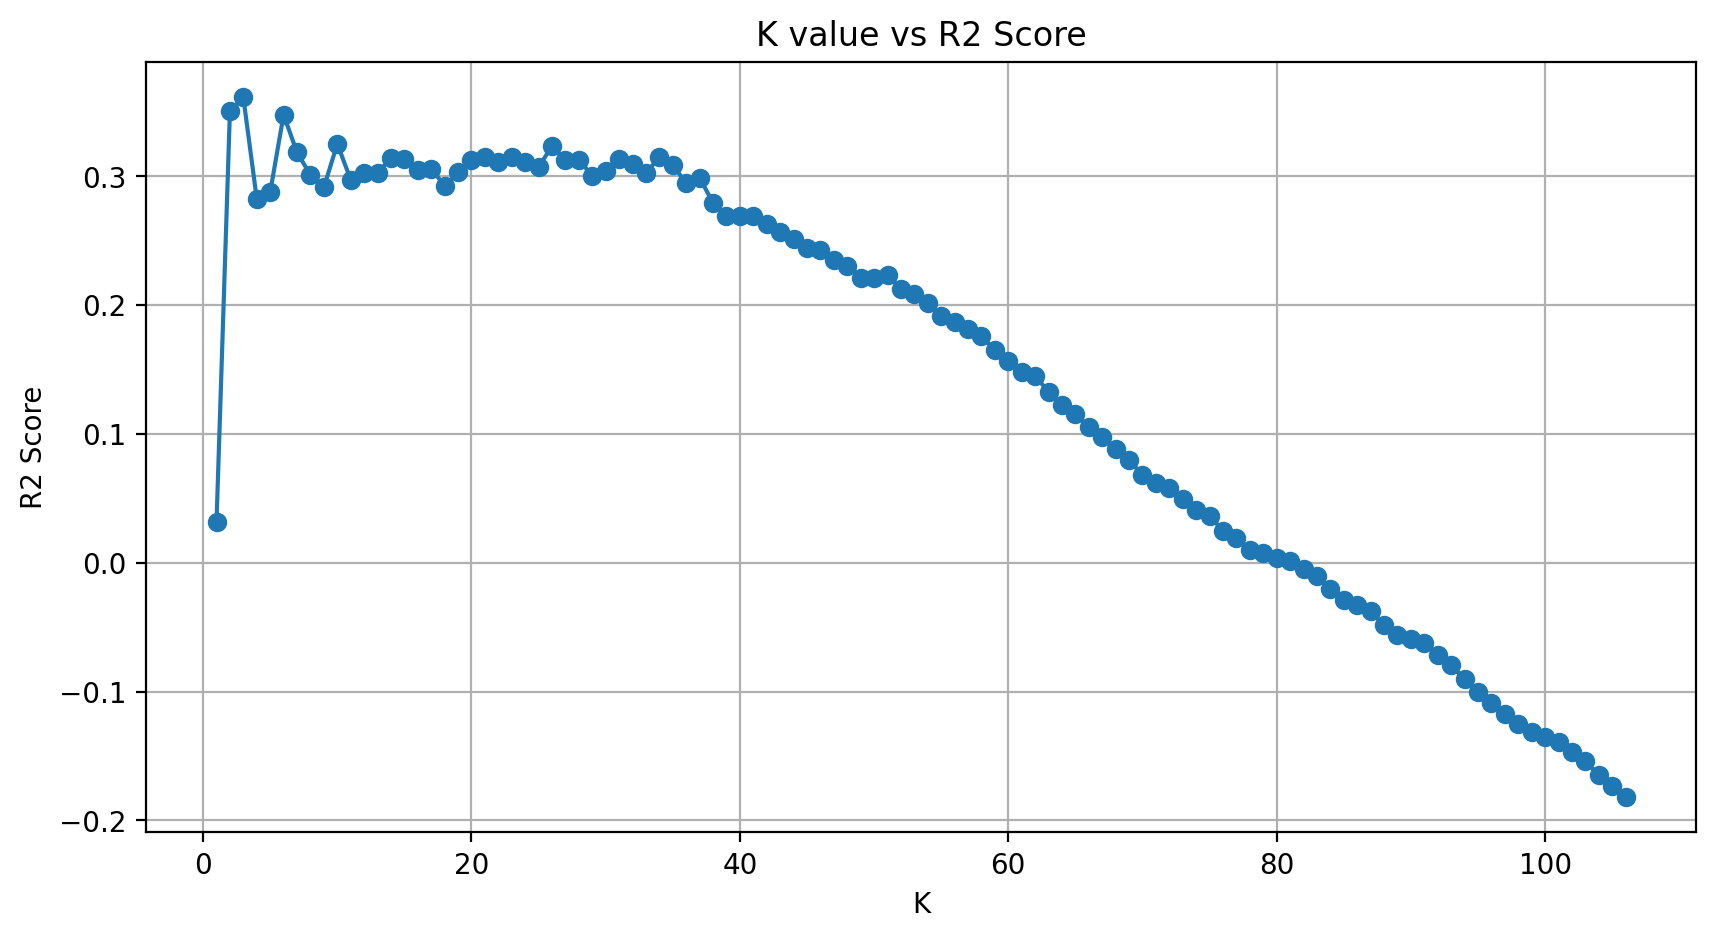

최고 성능 K: 3
최고 R2 Score: 0.3612911055686655


In [127]:
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor  
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, accuracy_score, confusion_matrix

air = pd.read_csv('content/airquality.csv')
air.interpolate(method='linear', inplace=True)
drop_cols = ['Month', 'Day']
air.drop(drop_cols, axis=1, inplace=True)

target = 'Ozone'

X = air.drop(target, axis=1)
y = air[target]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)

# KNN은 반드시 스케일링이 필요합니다!
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 최적의 K를 찾기 위한 테스트
range_k = range(1, len(X_train_scaled))
scores = []
for k in range_k:
    model = KNeighborsRegressor(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    scores.append(r2_score(y_test, y_pred))
# 시각화
plt.figure(figsize=(10, 5))
plt.plot(range_k, scores, marker='o')
plt.title('K value vs R2 Score')
plt.xlabel('K')
plt.ylabel('R2 Score')
plt.grid()
plt.show()
print(f"최고 성능 K: {scores.index(max(scores)) + 1}")
print(f"최고 R2 Score: {max(scores)}")


Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64
0이 하나라도 포함된 행의 수: 376
전체 데이터 대비 비율: 48.96%
MAE: 0.19047619047619047
accuracy_score: 0.8095238095238095
confusion_matrix: [[138   8]
 [ 36  49]]


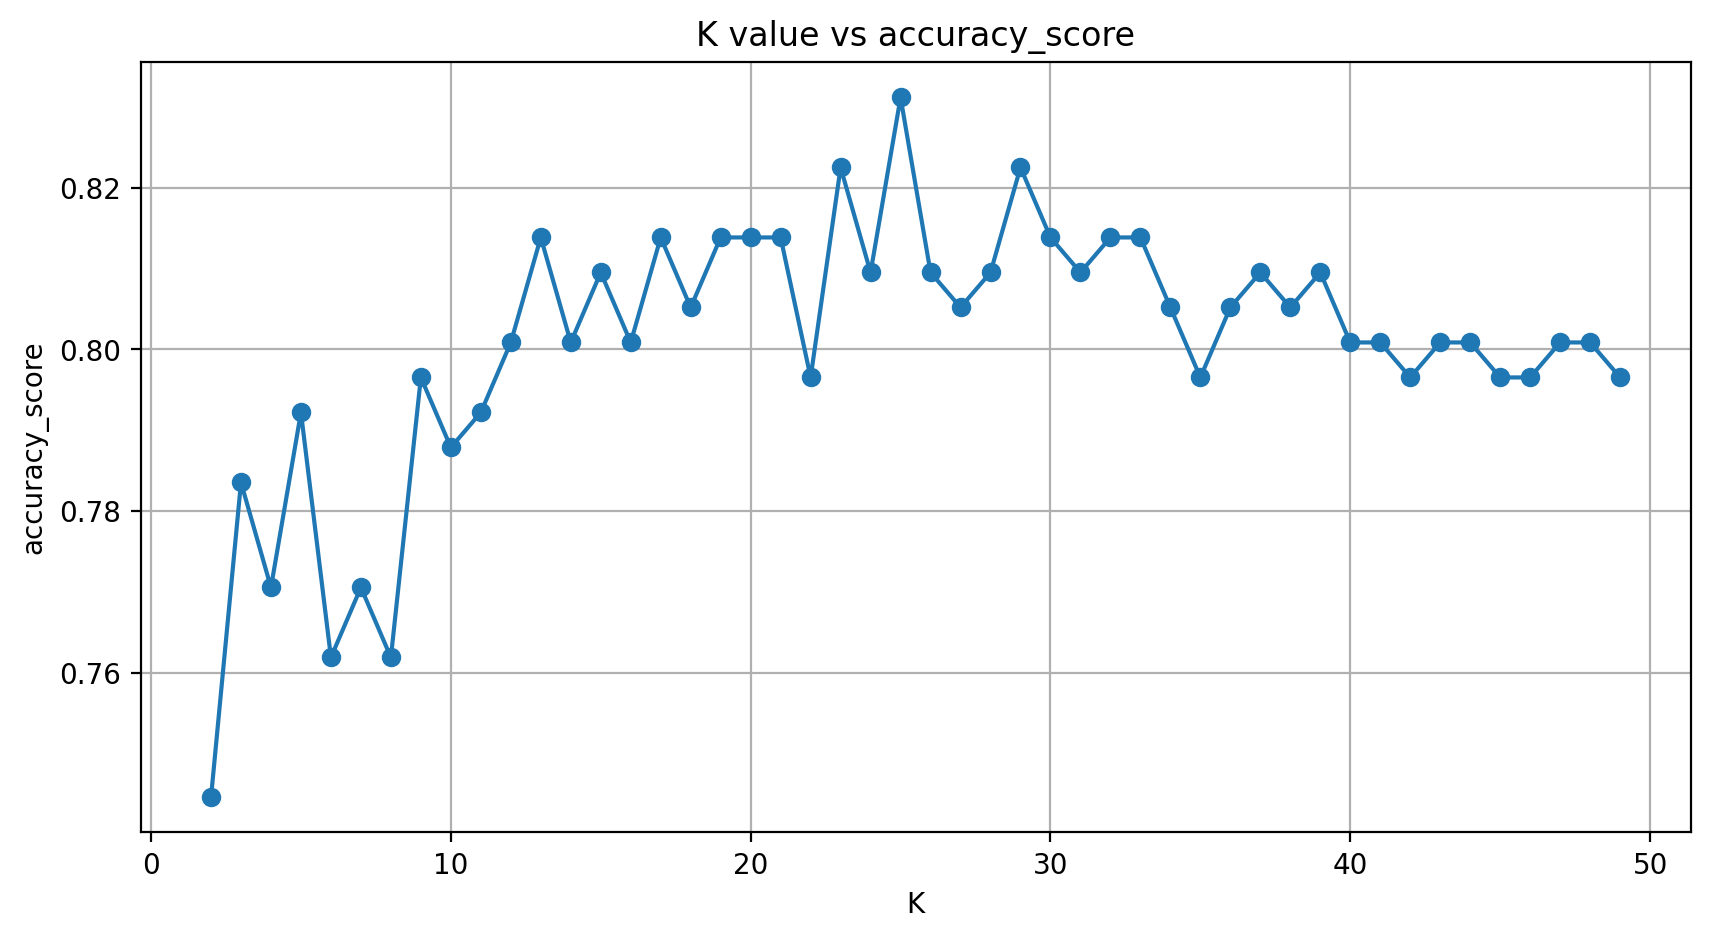

최고 성능 K: 24
최고 accuracy_score: 0.8311688311688312


In [ ]:
dia = pd.read_csv('content/diabetes.csv')

# 0의 개수를 확인하고 싶은 컬럼들
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
# 각 컬럼별로 값이 0인 데이터의 개수 출력
print((dia[cols] == 0).sum())

# 지정한 컬럼들 중 하나라도 0이 있는 행들 추출
zero_rows = dia[(dia[cols] == 0).any(axis=1)]
print(f"0이 하나라도 포함된 행의 수: {len(zero_rows)}")
print(f"전체 데이터 대비 비율: {len(zero_rows) / len(dia) * 100:.2f}%")

dia[cols] = dia[cols].replace(0, np.nan)

target = 'Outcome'
X = dia.drop(target, axis=1)
y = dia[target]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)

# 3. 학습 데이터(X_train)의 중앙값을 구해서 변수에 저장
train_median = X_train.median()
# 4. 학습 데이터와 평가 데이터의 빈 곳을 '학습 데이터의 중앙값'으로 채움
X_train = X_train.fillna(train_median)
X_test = X_test.fillna(train_median)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=24)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print('MAE:', mean_absolute_error(y_test,y_pred))
print('accuracy_score:', accuracy_score(y_test,y_pred))
print('confusion_matrix:', confusion_matrix(y_test,y_pred))

# 최적의 K를 찾기 위한 테스트
range_k = range(2, 50)
scores = []
for k in range_k:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred))
# 시각화
plt.figure(figsize=(10, 5))
plt.plot(range_k, scores, marker='o')
plt.title('K value vs accuracy_score')
plt.xlabel('K')
plt.ylabel('accuracy_score')
plt.grid()
plt.show()
print(f"최고 성능 K: {scores.index(max(scores)) + 1}")
print(f"최고 accuracy_score: {max(scores)}")

In [147]:
attr = pd.read_csv('content/attrition.csv')

attr.drop('EmployeeNumber', axis=1, inplace=True)

target = 'Attrition'
X = pd.get_dummies(data=attr.drop(target, axis=1), columns=[ 'Gender', 'JobSatisfaction', 'MaritalStatus', 'OverTime'], drop_first=True)
y = attr[target]


X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)


scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = KNeighborsClassifier(n_neighbors=3)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print('MAE:', mean_absolute_error(y_test,y_pred))
print('accuracy_score:', accuracy_score(y_test,y_pred))
print('confusion_matrix:', confusion_matrix(y_test,y_pred))
# 2. 종합 리포트 출력 (가장 추천하는 방법)
print('\\n[ Classification Report ]')
print(classification_report(y_test, y_pred))

# 1. 각 클래스에 속할 확률 구하기
# 결과는 [0일 확률, 1일 확률] 형태의 리스트로 나옵니다.
y_prob = model.predict_proba(X_test_scaled)
# 2. 임계값(Threshold) 설정
# 예: 확률이 30%만 넘어도 '퇴사(1)'라고 예측하겠다!
threshold = 0.3
y_pred_new = (y_prob[:, 1] > threshold).astype(int)
# 3. 결과 확인
print(f'임계값 {threshold} 기준 Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_new))
print('\\nClassification Report:')
print(classification_report(y_test, y_pred_new))

MAE: 0.17548746518105848
accuracy_score: 0.8245125348189415
confusion_matrix: [[283  17]
 [ 46  13]]
\n[ Classification Report ]
              precision    recall  f1-score   support

           0       0.86      0.94      0.90       300
           1       0.43      0.22      0.29        59

    accuracy                           0.82       359
   macro avg       0.65      0.58      0.60       359
weighted avg       0.79      0.82      0.80       359

임계값 0.3 기준 Confusion Matrix:
[[201  99]
 [ 19  40]]
\nClassification Report:
              precision    recall  f1-score   support

           0       0.91      0.67      0.77       300
           1       0.29      0.68      0.40        59

    accuracy                           0.67       359
   macro avg       0.60      0.67      0.59       359
weighted avg       0.81      0.67      0.71       359



Train set shape: (623, 9)
Test set shape: (268, 9)


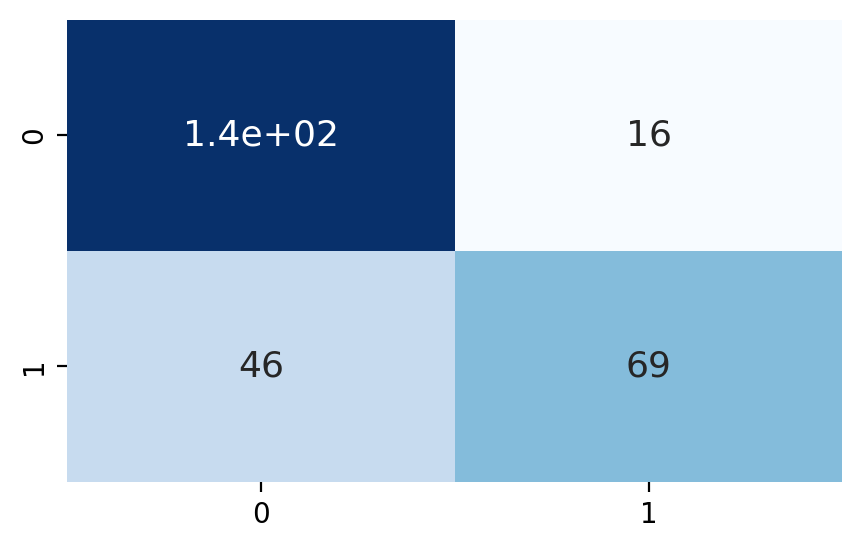

              precision    recall  f1-score   support

           0       0.75      0.90      0.82       153
           1       0.81      0.60      0.69       115

    accuracy                           0.77       268
   macro avg       0.78      0.75      0.75       268
weighted avg       0.78      0.77      0.76       268



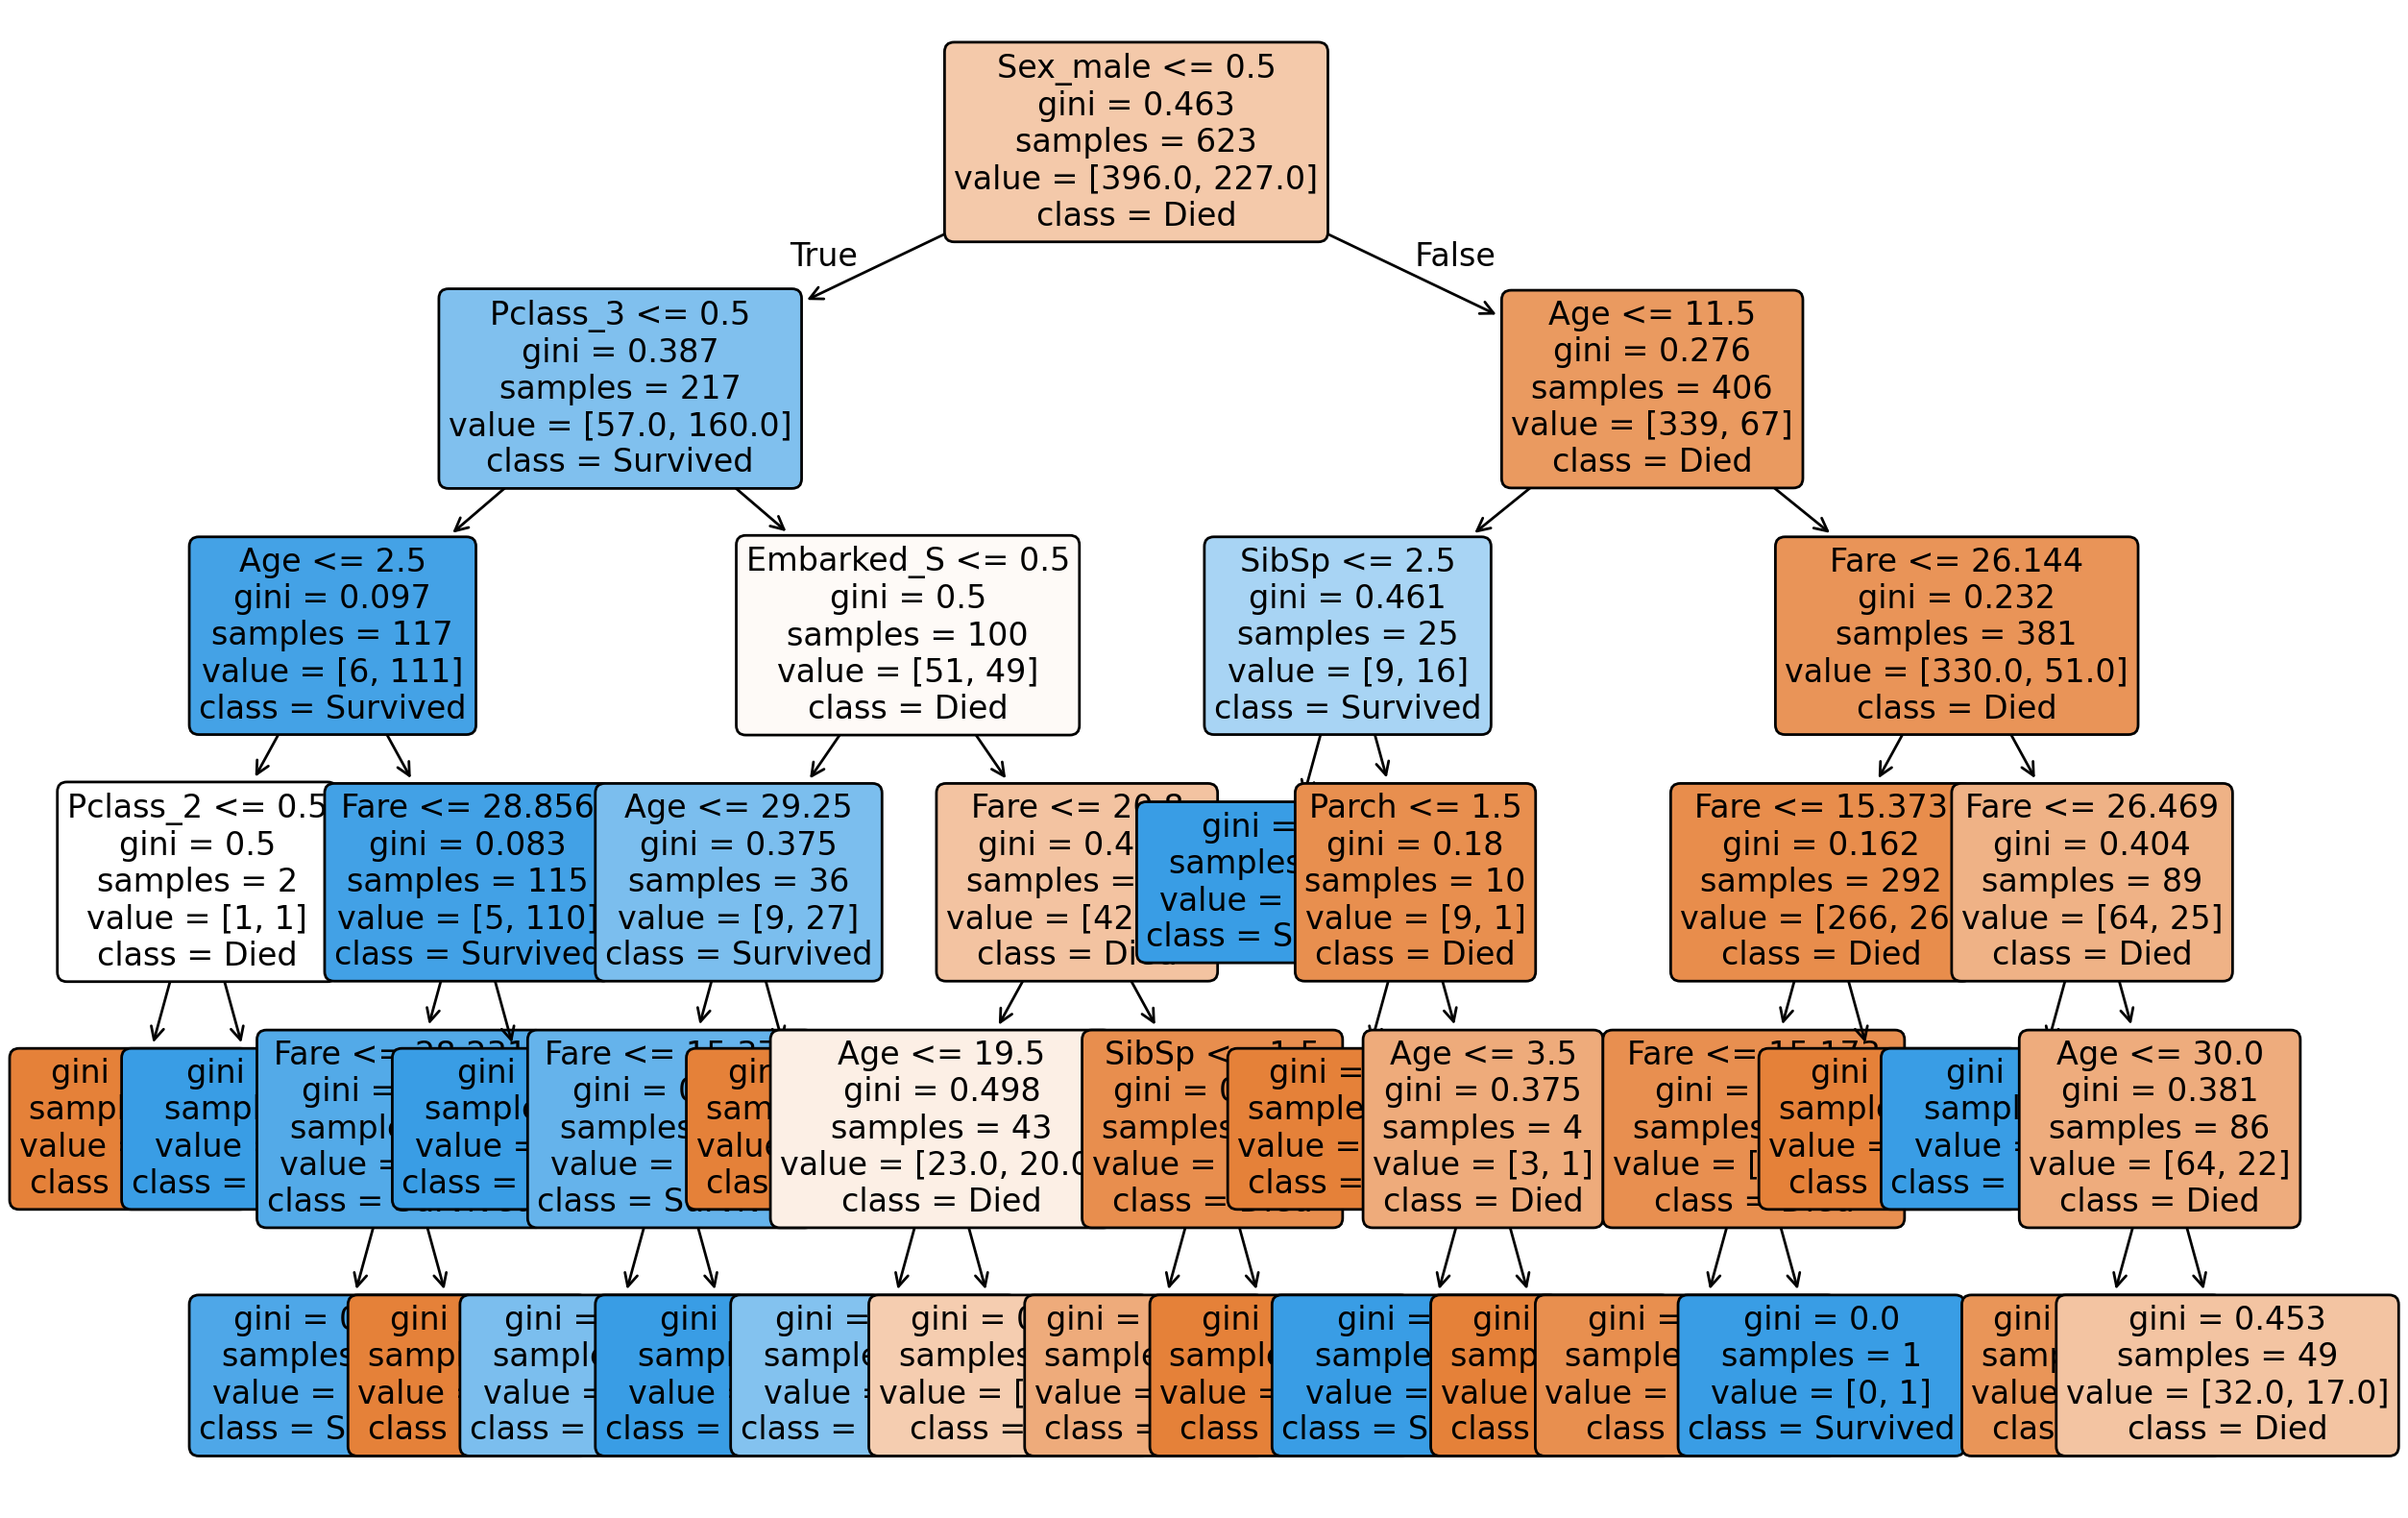

In [171]:
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

titanic = pd.read_csv('content/titanic_train.csv')

titanic.drop(['PassengerId', 'Name', 'Cabin', 'Ticket'], axis=1, inplace=True)

titanic['Age'] = titanic['Age'].fillna(titanic['Age'].median())
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])

target = 'Survived'

x = pd.get_dummies(data=titanic.drop(target, axis=1), columns=['Sex','Embarked', 'Pclass'], drop_first=True)
y = titanic[target]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=1)

print(f"Train set shape: {x_train.shape}")
print(f"Test set shape: {x_test.shape}")

model = DecisionTreeClassifier(max_depth=5, random_state=1)

model.fit(x_train, y_train)
y_pred = model.predict(x_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,
            annot=True, 
            cbar=False,
            cmap='Blues',
            annot_kws={'size':13})
plt.show()

print(classification_report(y_test, y_pred))

# 그래프 크기 설정
plt.figure(figsize=(15, 10))
# 나무 그리기
plot_tree(model, 
          feature_names=x.columns,   
          class_names=['Died', 'Survived'],
          filled=True,                  
          rounded=True,                 
          fontsize=12)                  
plt.show()

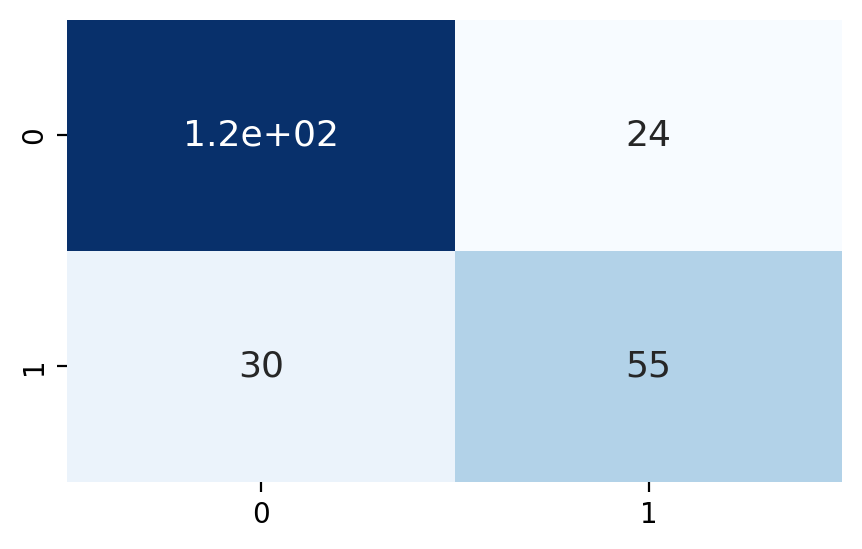

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       146
           1       0.70      0.65      0.67        85

    accuracy                           0.77       231
   macro avg       0.75      0.74      0.74       231
weighted avg       0.76      0.77      0.76       231



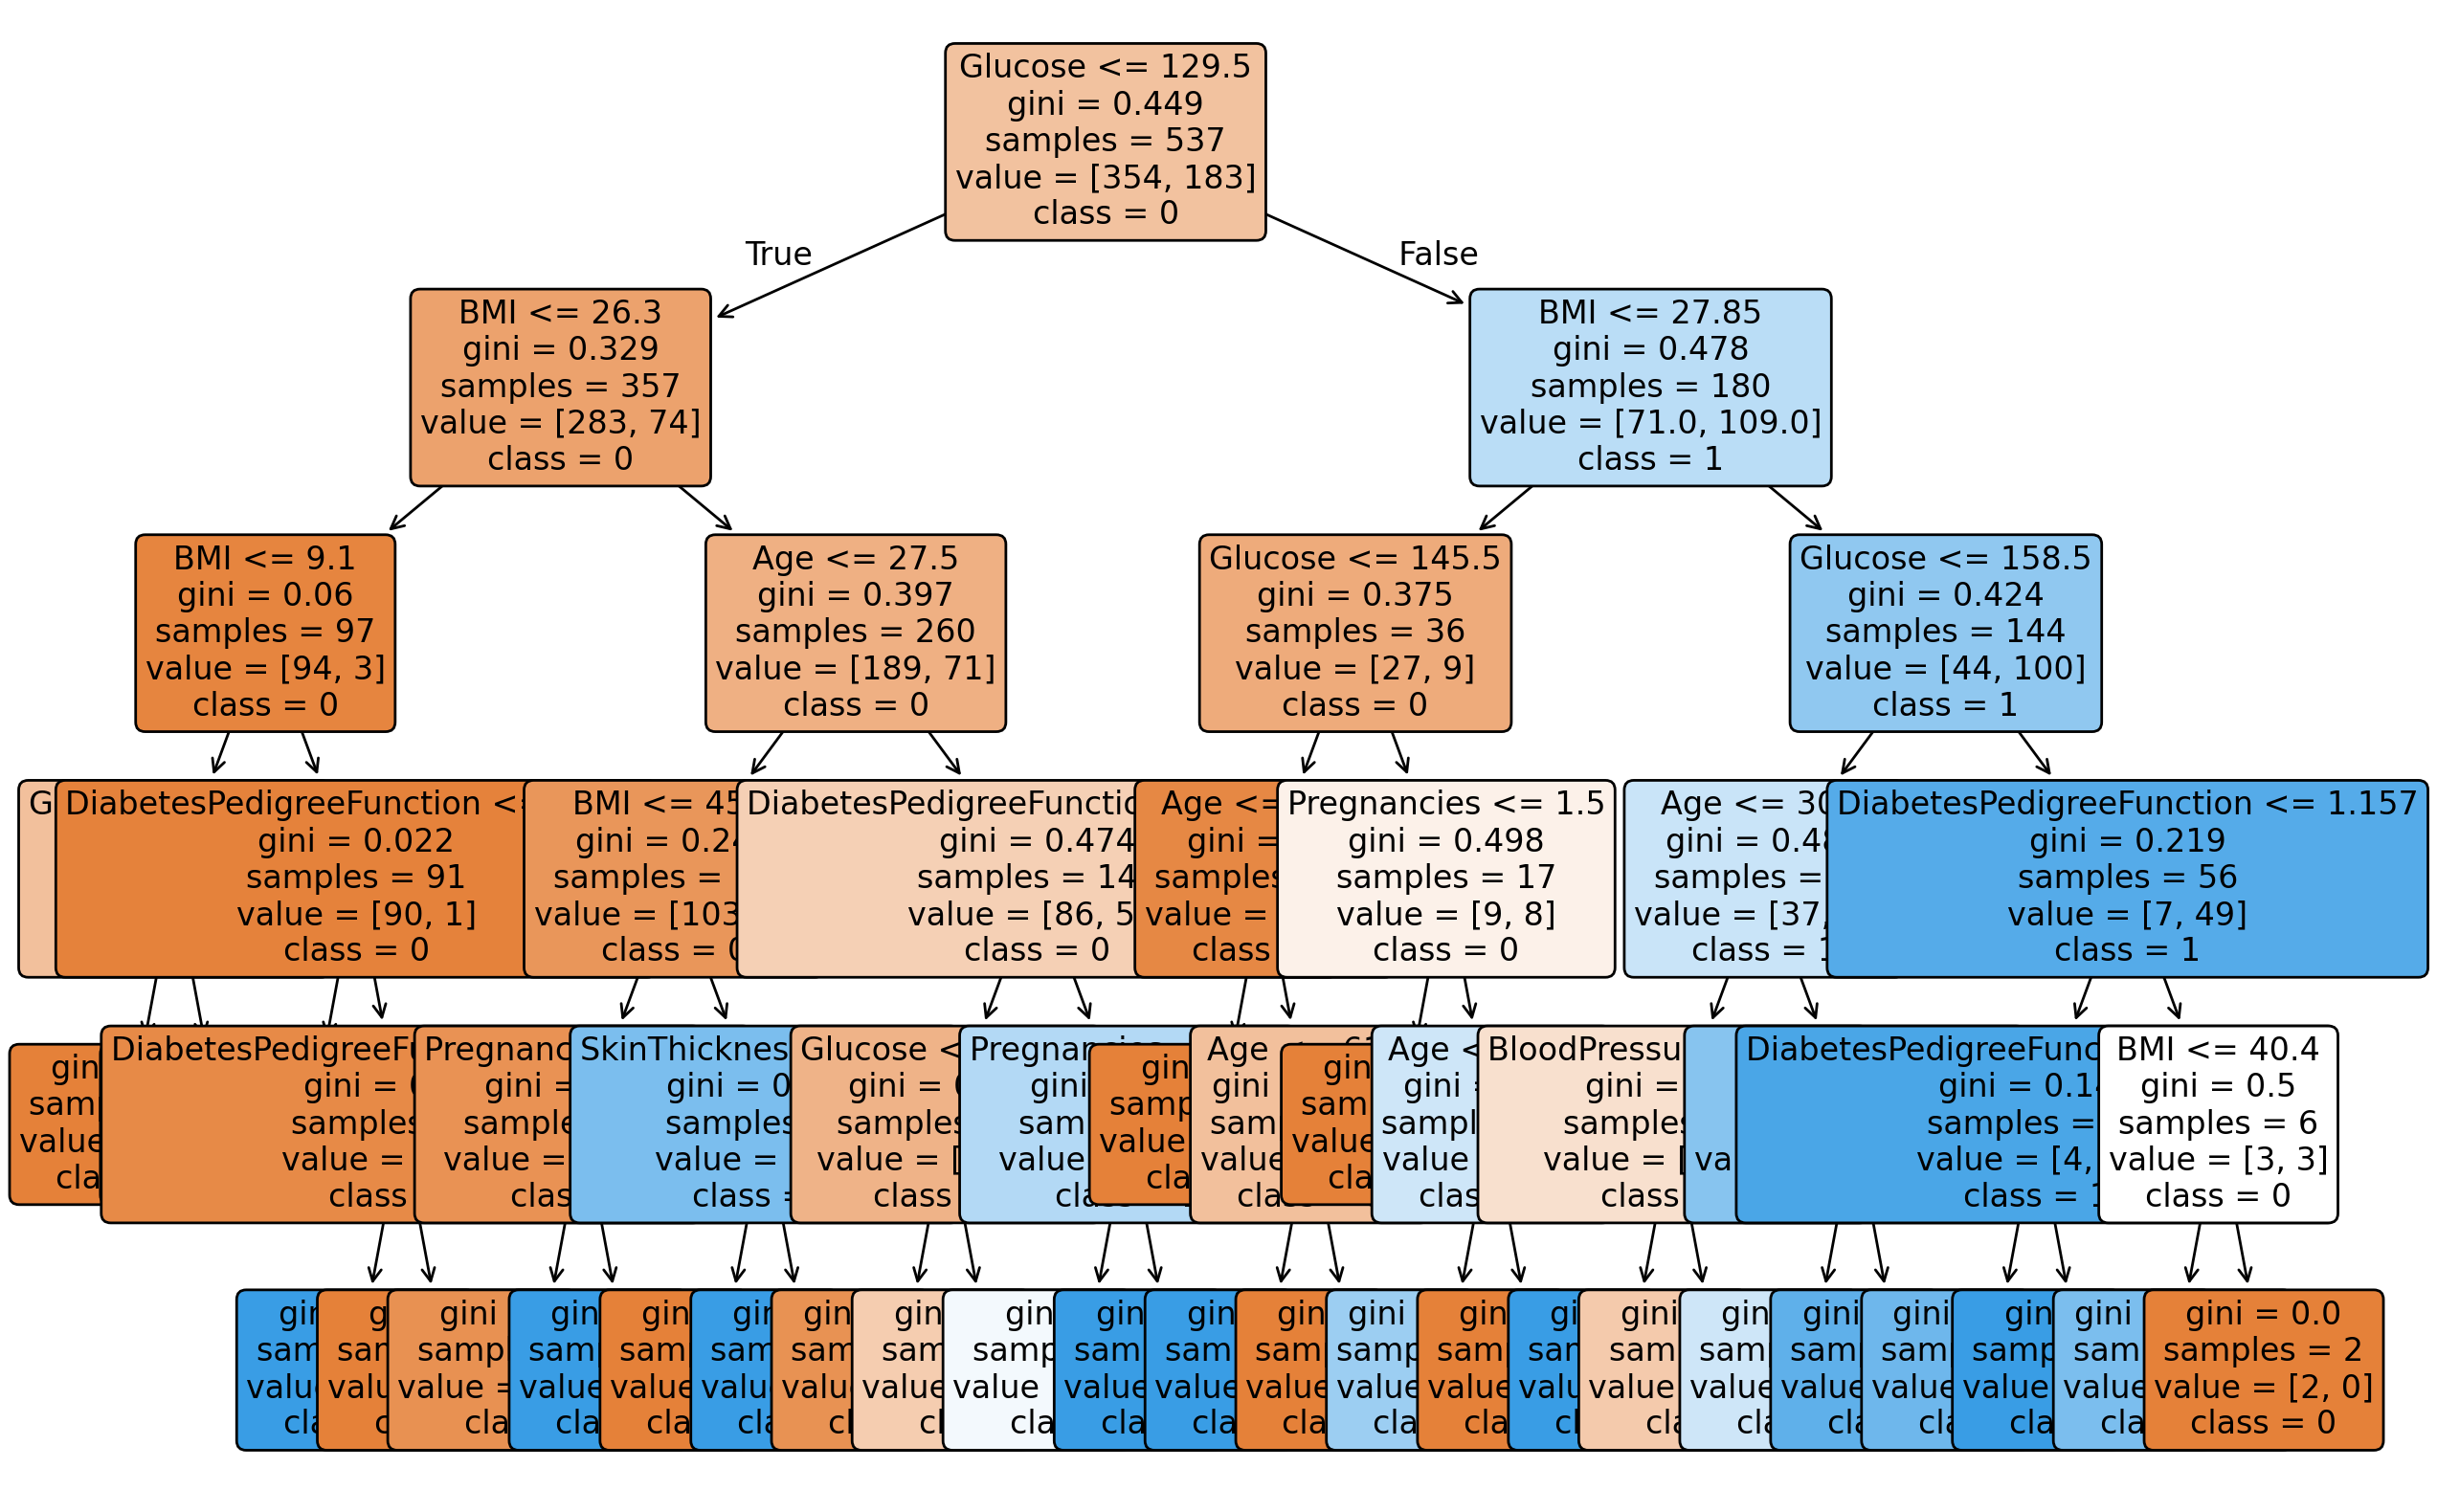

In [196]:
dia = pd.read_csv('content/diabetes.csv')

target = 'Outcome'
X = dia.drop(target, axis=1)
y = dia[target]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)

model = DecisionTreeClassifier(max_depth=5, random_state=1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,
            annot=True, 
            cbar=False,
            cmap='Blues',
            annot_kws={'size':13})
plt.show()

print(classification_report(y_test, y_pred))

# 그래프 크기 설정
plt.figure(figsize=(15, 10))
# 나무 그리기
plot_tree(model, 
          feature_names=X.columns,   
          class_names=model.classes_.astype(str),
          filled=True,                  
          rounded=True,                 
          fontsize=12)                  
plt.show()

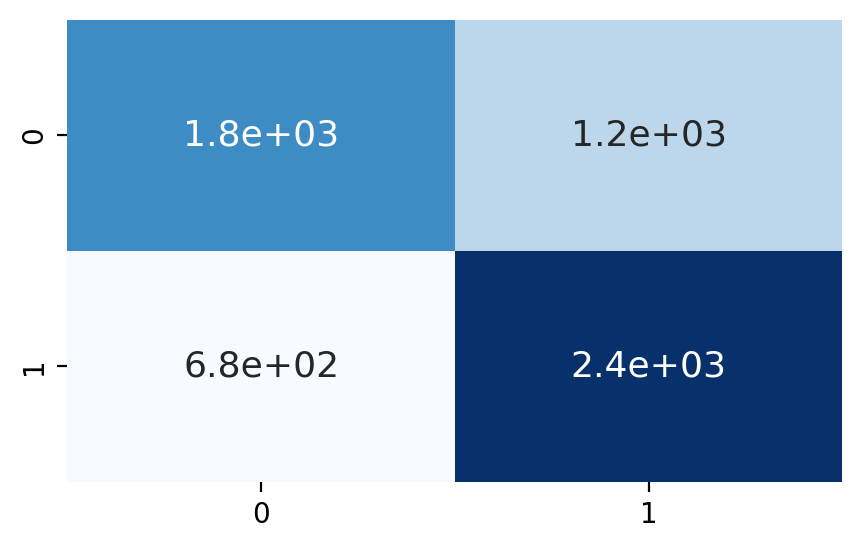

              precision    recall  f1-score   support

       LEAVE       0.72      0.60      0.66      2935
        STAY       0.67      0.78      0.72      3065

    accuracy                           0.69      6000
   macro avg       0.70      0.69      0.69      6000
weighted avg       0.70      0.69      0.69      6000



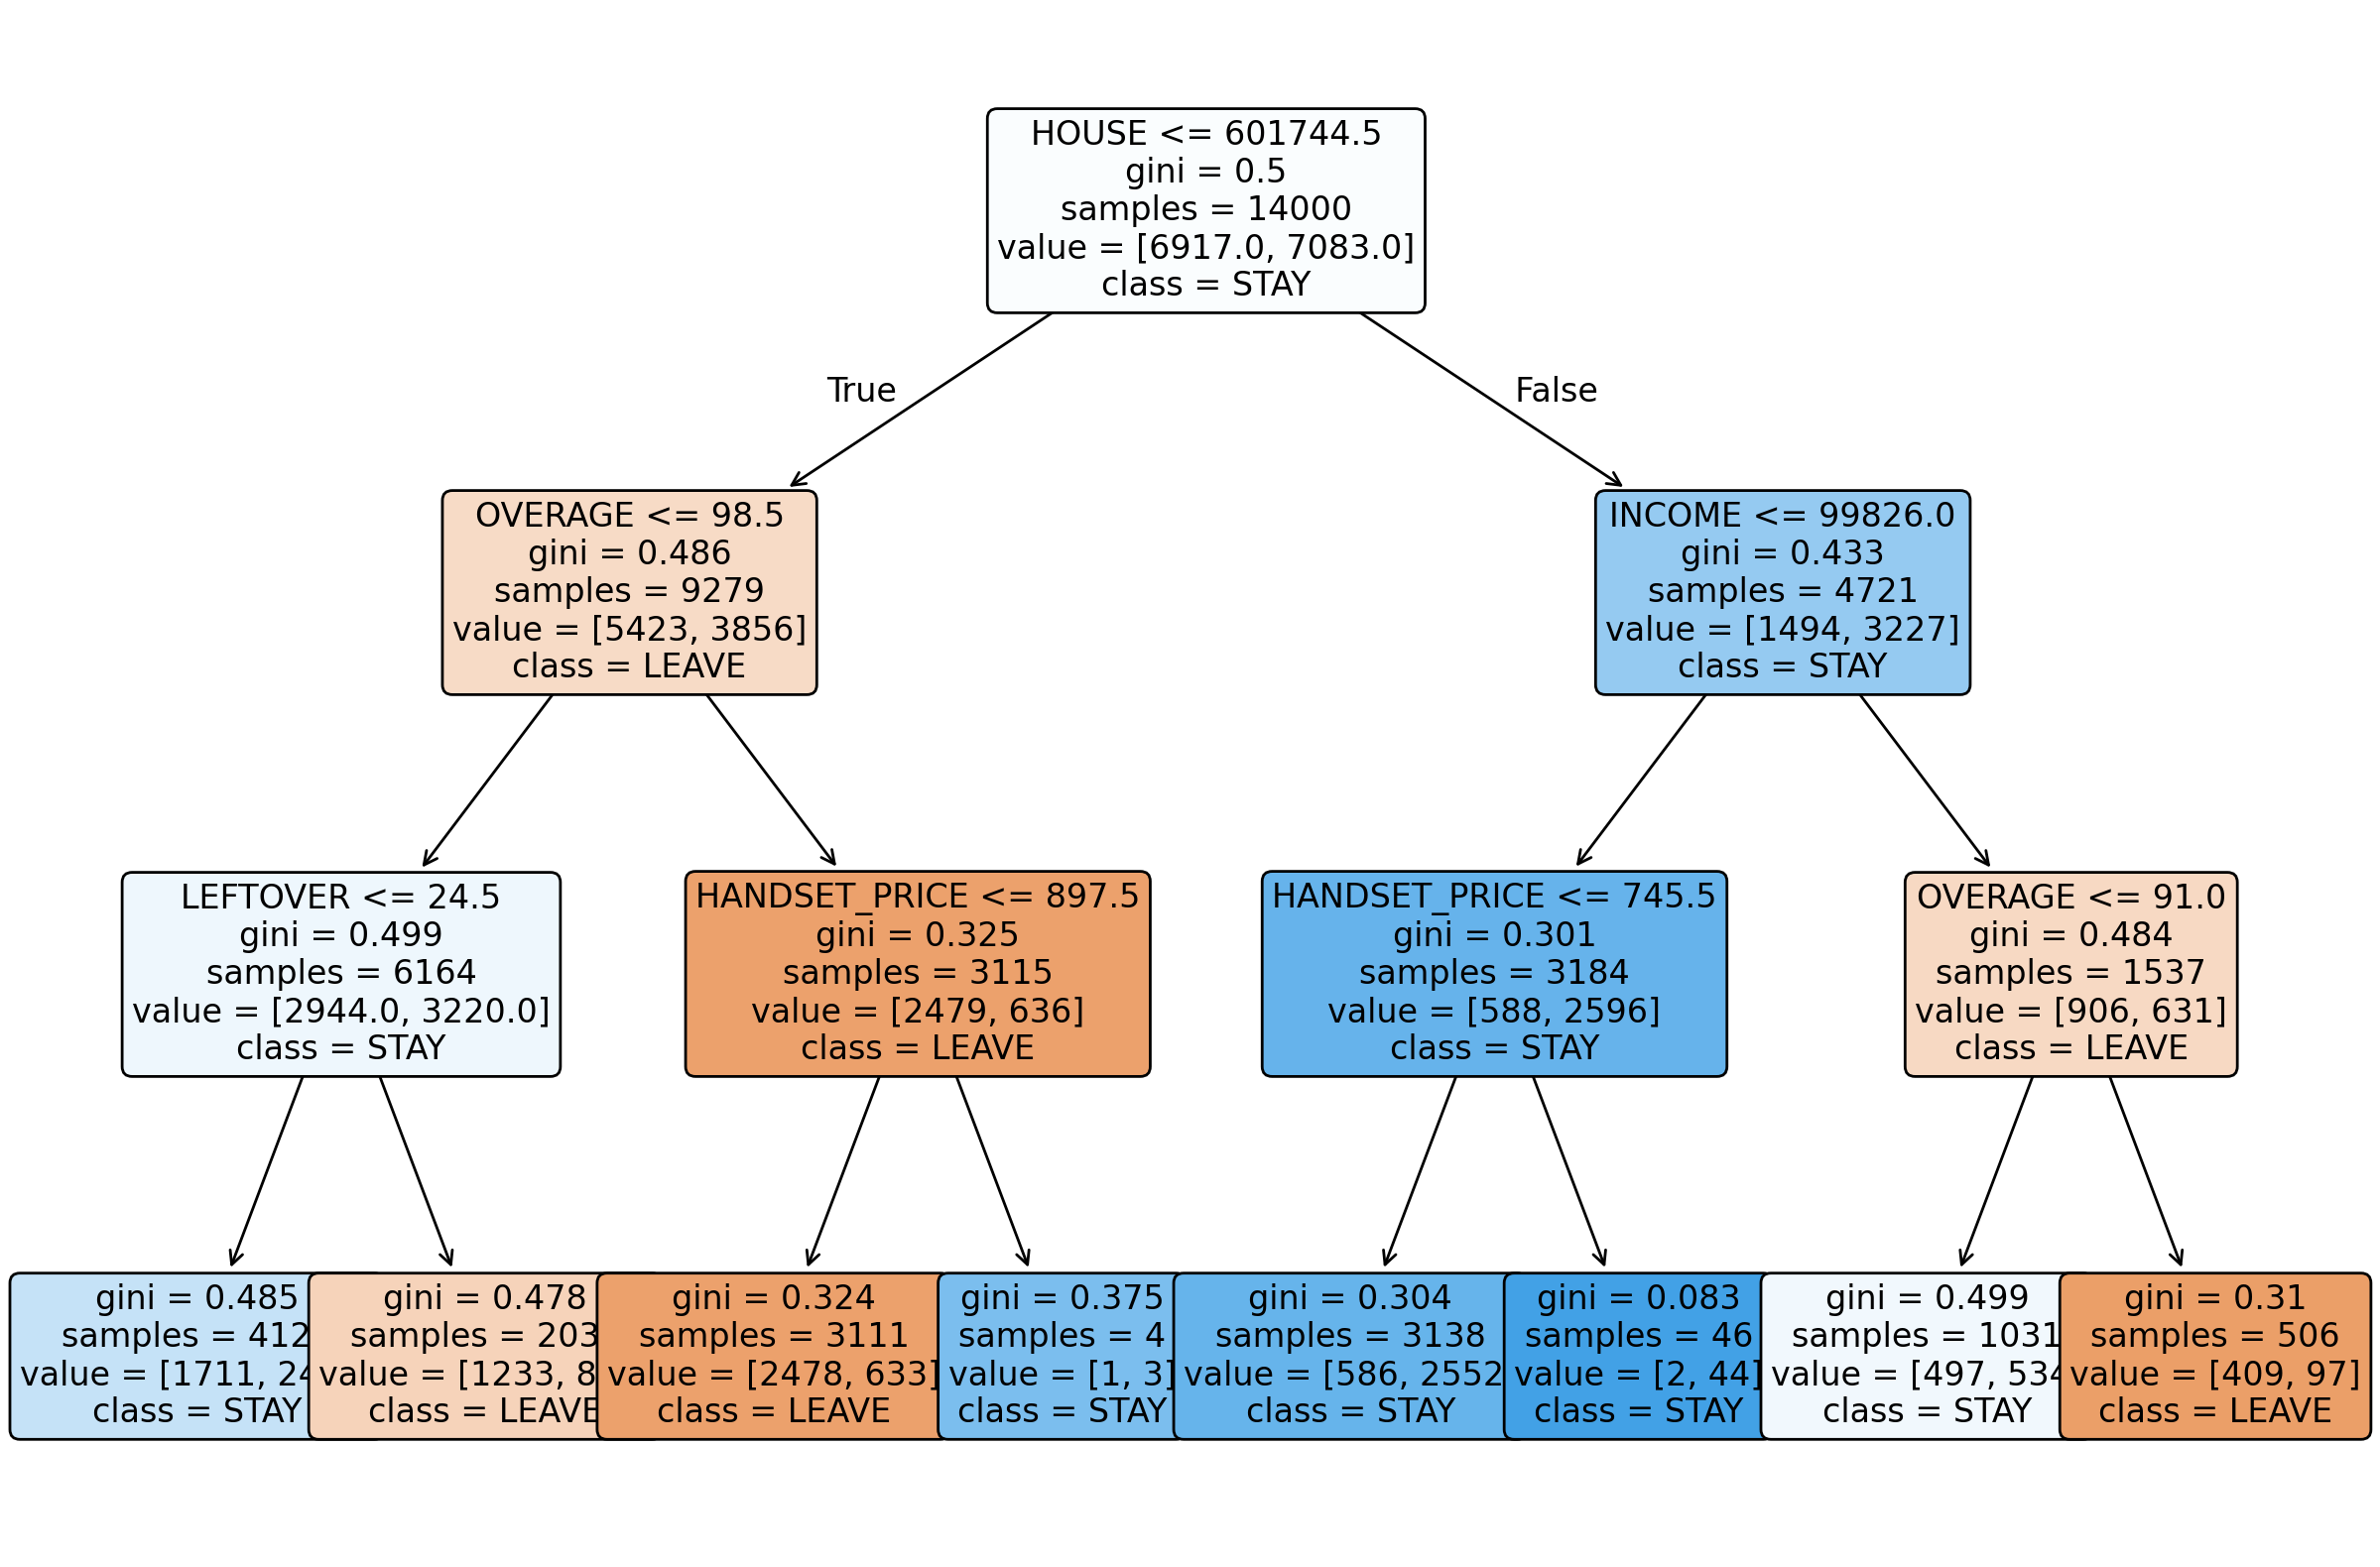

In [197]:
mobile = pd.read_csv('content/mobile_cust_churn.csv')

mobile.drop('id', axis=1, inplace=True)

target = 'CHURN'

X = pd.get_dummies(data=mobile.drop(target, axis=1), columns=['REPORTED_SATISFACTION', 'REPORTED_USAGE_LEVEL', 'CONSIDERING_CHANGE_OF_PLAN'], drop_first=True)
y = mobile[target]

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=1)

model = DecisionTreeClassifier(max_depth=3, random_state=1)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,3))
sns.heatmap(cm,
            annot=True, 
            cbar=False,
            cmap='Blues',
            annot_kws={'size':13})
plt.show()

print(classification_report(y_test, y_pred))

# 그래프 크기 설정
plt.figure(figsize=(15, 10))
# 나무 그리기
plot_tree(model, 
          feature_names=X.columns,   
          class_names=model.classes_.astype(str),
          filled=True,                  
          rounded=True,                 
          fontsize=12)                  
plt.show()

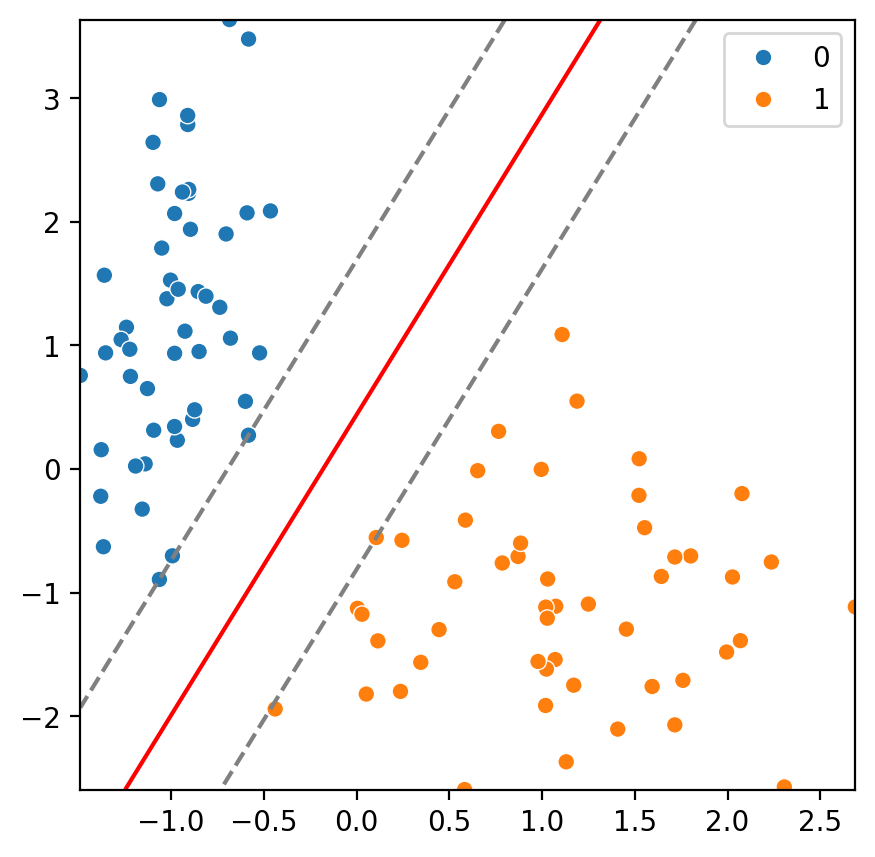

In [199]:
from sklearn.datasets import make_moons, make_classification
from sklearn.svm import SVC, SVR

# 시각화 함수 만들기
def svc_visualize(x, y, model, title=''):
    xx, yy = np.meshgrid(np.linspace(x[:, 0].min(), x[:, 0].max(), 50),
                         np.linspace(x[:, 1].min(), x[:, 1].max(), 50))
    Z = model.decision_function(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(5, 5))
    sns.scatterplot(x=x[:, 0], y=x[:, 1], hue=y)
    plt.contour(xx, yy, Z, levels=[-1, 0, 1],
                colors=['gray', 'red', 'gray'],
                linestyles=['--', '-', '--'])
    plt.title(title)
    plt.axis('tight')
    plt.show()

seed = 903
x, y = make_classification(n_samples=100,
                           n_features=2,
                           n_redundant=0,
                           weights=[0.5, 0.5],
                           n_clusters_per_class=1,
                           random_state=seed)

model = SVC(kernel='linear', C=10)
model.fit(x,y)
svc_visualize(x,y,model)

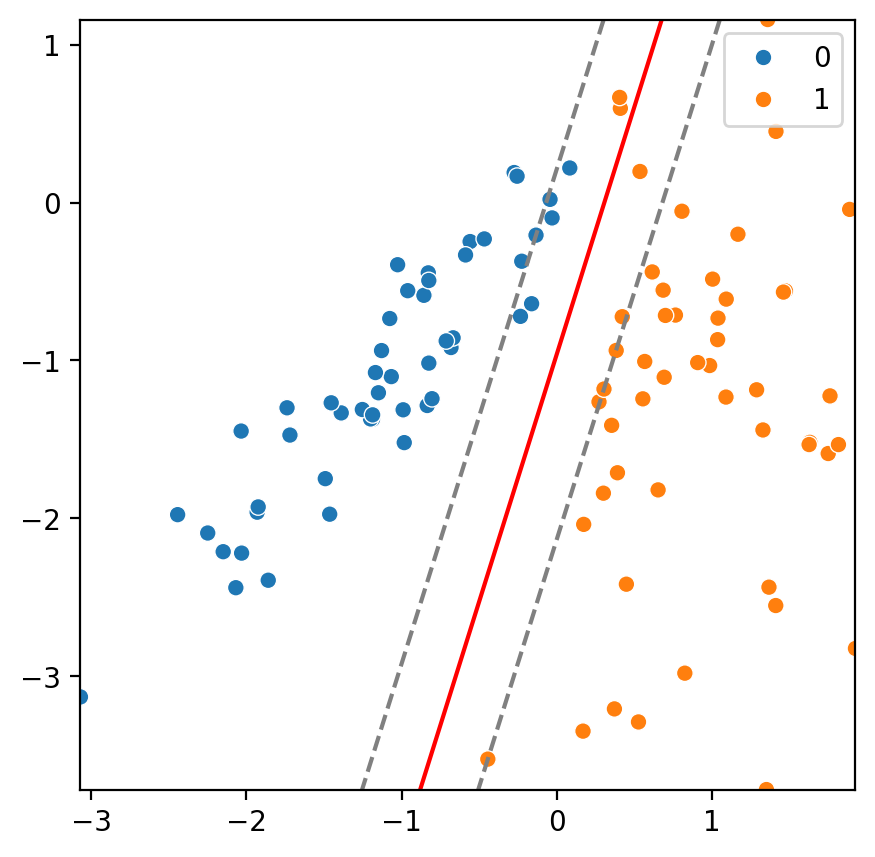

In [210]:
# 데이터 만들기
seed = 874
x, y = make_classification(n_features=2,
                           n_redundant=0,
                           weights=[0.5, 0.5],
                           n_clusters_per_class=1,
                           random_state=seed)

model = SVC(kernel='linear', C=1)
model.fit(x,y)
svc_visualize(x,y,model)


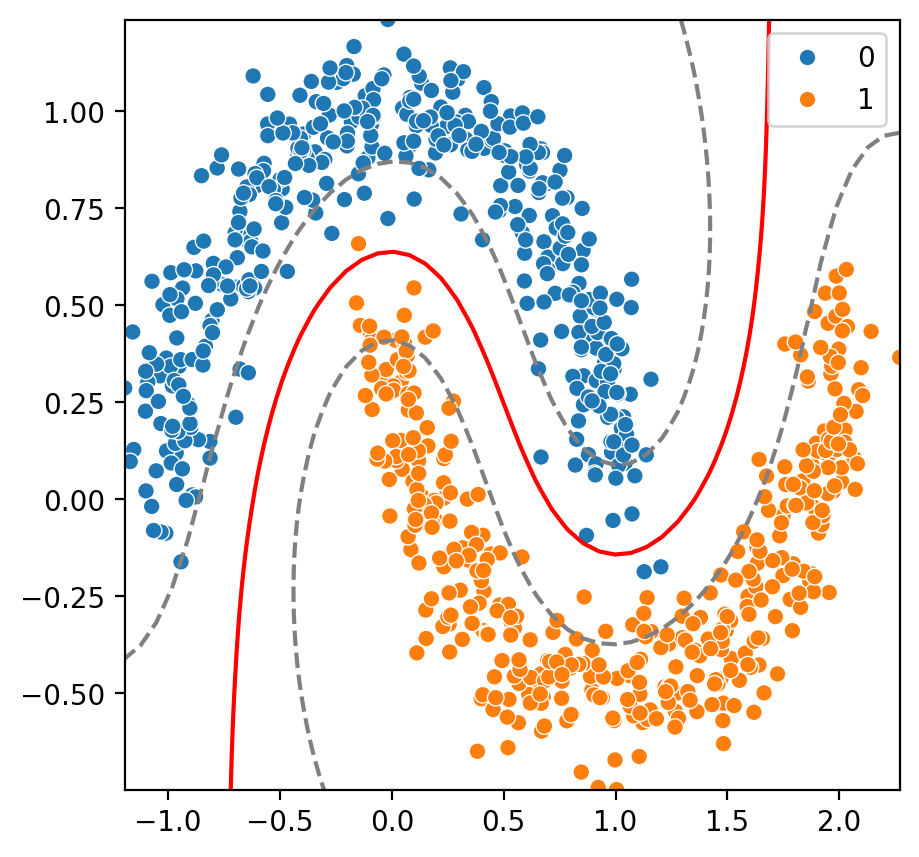

In [225]:
# 데이터 만들기
x, y = make_moons(n_samples=800, noise=.1, random_state=10)

model = SVC(kernel='rbf', C=1, gamma=1)
model.fit(x,y)
svc_visualize(x,y,model)

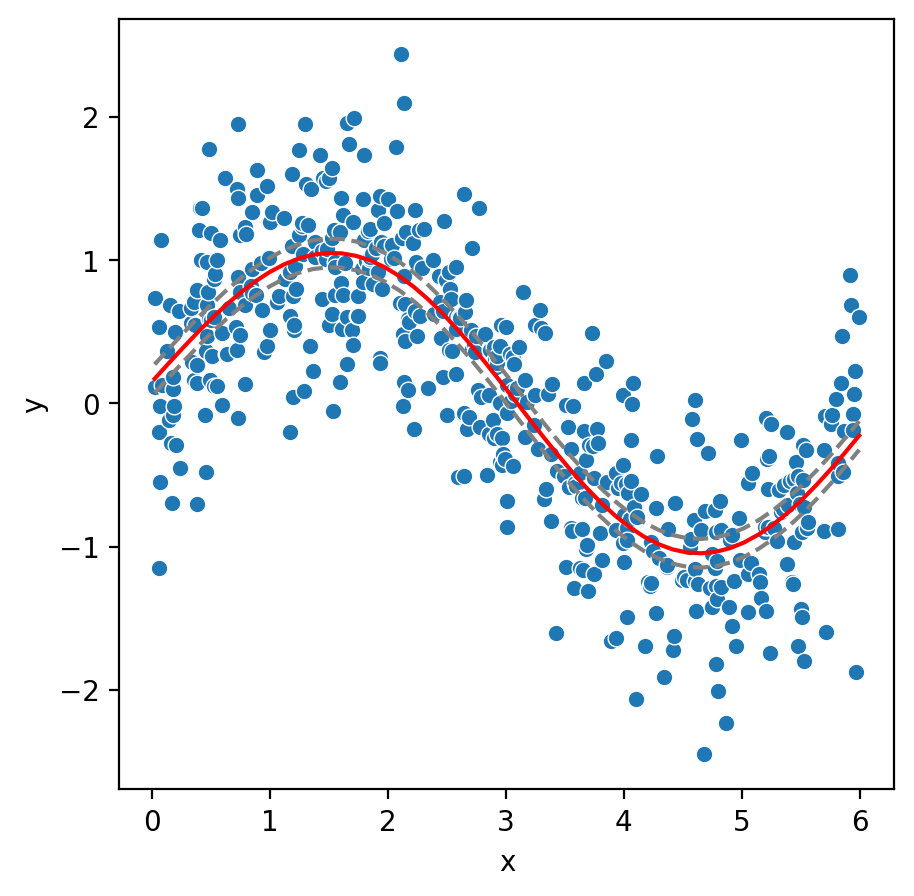

In [246]:
# 시각화 함수 만들기
def svr_visualize(x, y, model, title=''):
    xx = np.linspace(x.min(), x.max(), 50)
    xx = xx.reshape((len(xx), 1))
    yy = model.predict(xx)

    plt.figure(figsize=(5, 5))
    plt.scatter(x, y, edgecolors='w', linewidths=0.5)
    plt.plot(xx, yy, color = 'r')
    plt.plot(xx, yy + model.epsilon, color = 'gray', linestyle='--')
    plt.plot(xx, yy - model.epsilon, color = 'gray', linestyle='--')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.axis('tight')
    plt.show()

numSamples = 500
x = np.sort(6 * np.random.rand(numSamples, 1), axis=0)
y = np.sin(x).ravel()
y = y + 0.5 * (np.random.randn(numSamples))

model = SVR(kernel='rbf', C=1, gamma=0.1)
model.fit(x,y)
svr_visualize(x,y,model)